In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('student_data_100000.csv')

In [4]:
df.head()

,attendance,study_hours,past_failures,assignments_completed_pct,parental_education,family_income,extracurricular,internet_access,previous_grade,final_score,risk_category
0,87.42,10.12,2,100.00,Secondary,Low,Yes,Yes,46.80,76.08,Safe
1,71.54,1.38,3,36.70,Secondary,High,Yes,Yes,48.05,43.21,High-Risk
2,91.19,8.30,5,64.38,Secondary,Low,No,Yes,69.40,60.89,At-Risk
3,100.00,3.52,4,93.77,Secondary,Low,No,No,58.07,45.47,At-Risk
4,69.15,4.69,1,72.36,Primary,Low,Yes,Yes,50.55,37.15,High-Risk


In [5]:
df.shape

(100000, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   attendance                 99000 non-null   float64
 1   study_hours                99000 non-null   float64
 2   past_failures              100000 non-null  int64  
 3   assignments_completed_pct  100000 non-null  float64
 4   parental_education         100000 non-null  str    
 5   family_income              100000 non-null  str    
 6   extracurricular            100000 non-null  str    
 7   internet_access            100000 non-null  str    
 8   previous_grade             100000 non-null  float64
 9   final_score                100000 non-null  float64
 10  risk_category              100000 non-null  str    
dtypes: float64(5), int64(1), str(5)
memory usage: 10.7 MB


In [7]:
df.describe()

,attendance,study_hours,past_failures,assignments_completed_pct,previous_grade,final_score
count,99000.000000,99000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,72.972567,6.101901,1.848650,72.929616,72.967067,62.968236
std,21.562735,3.722512,1.491297,21.656246,21.624269,15.888285
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58.150000,3.300000,1.000000,58.090000,58.190000,52.220000
50%,75.065000,6.000000,2.000000,75.070000,75.040000,63.160000
75%,91.940000,8.700000,3.000000,91.830000,91.890000,73.990000
max,100.000000,15.000000,5.000000,100.000000,100.000000,100.000000


In [8]:
df['risk_category'].unique()

<ArrowStringArray>
['Safe', 'High-Risk', 'At-Risk']
Length: 3, dtype: str

In [9]:
numeric_columns=['attendance','study_hours','past_failures','assignments_completed_pct','previous_grade','final_score']

In [10]:
df.skew(numeric_only=True)

attendance                  -0.542913
study_hours                  0.215007
past_failures                0.348892
assignments_completed_pct   -0.576017
previous_grade              -0.571161
final_score                 -0.115524
dtype: float64

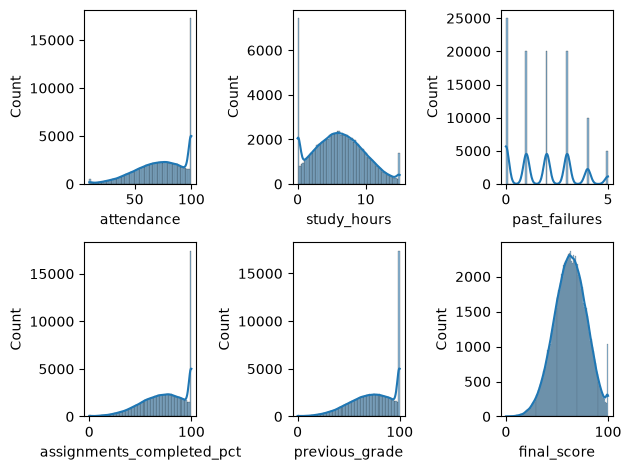

In [11]:
def plotting(var,ind):
    plt.subplot(2,3,ind)
    sns.histplot(df[var],kde=True)
for ind,col in enumerate(numeric_columns):
    plotting(col,ind+1)
plt.tight_layout()

In [12]:
atd_mean=df[df['attendance'].isna()==False]['attendance'].mean()

In [13]:
std_hr_mean=df[df['study_hours'].isna()==False]['study_hours'].mean()

In [14]:
df['attendance']=df['attendance'].fillna(atd_mean)

In [15]:
df['study_hours']=df['study_hours'].fillna(std_hr_mean)

In [16]:
df.describe()

,attendance,study_hours,past_failures,assignments_completed_pct,previous_grade,final_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,72.972567,6.101901,1.848650,72.929616,72.967067,62.968236
std,21.454649,3.703853,1.491297,21.656246,21.624269,15.888285
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58.360000,3.340000,1.000000,58.090000,58.190000,52.220000
50%,74.740000,6.050000,2.000000,75.070000,75.040000,63.160000
75%,91.740000,8.660000,3.000000,91.830000,91.890000,73.990000
max,100.000000,15.000000,5.000000,100.000000,100.000000,100.000000


In [17]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [18]:
df_encoded=df_encoded.astype(int)

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler=StandardScaler()
numeric_columns=['attendance','study_hours','past_failures','assignments_completed_pct','previous_grade','final_score']
df_encoded[numeric_columns]=scaler.fit_transform(df[numeric_columns])

In [21]:
df_encoded.head()

,attendance,study_hours,past_failures,assignments_completed_pct,previous_grade,final_score,parental_education_Primary,parental_education_Secondary,parental_education_none,family_income_Low,family_income_Medium,extracurricular_Yes,internet_access_Yes,risk_category_High-Risk,risk_category_Safe
0,0.673397,1.084848,0.101489,1.250010,-1.210085,0.825251,0,1,0,1,0,1,1,0,1
1,-0.066772,-1.274868,0.772050,-1.672949,-1.152279,-1.243579,0,1,0,0,0,1,1,1,0
2,0.849118,0.593466,2.113172,-0.394790,-0.164957,-0.130804,0,1,0,1,0,0,1,0,0
3,1.259753,-0.697089,1.442611,0.962332,-0.688908,-1.101335,0,1,0,1,0,0,0,0,0
4,-0.178171,-0.381200,-0.569071,-0.026303,-1.036668,-1.624994,1,0,0,1,0,1,1,1,0


<Axes: >

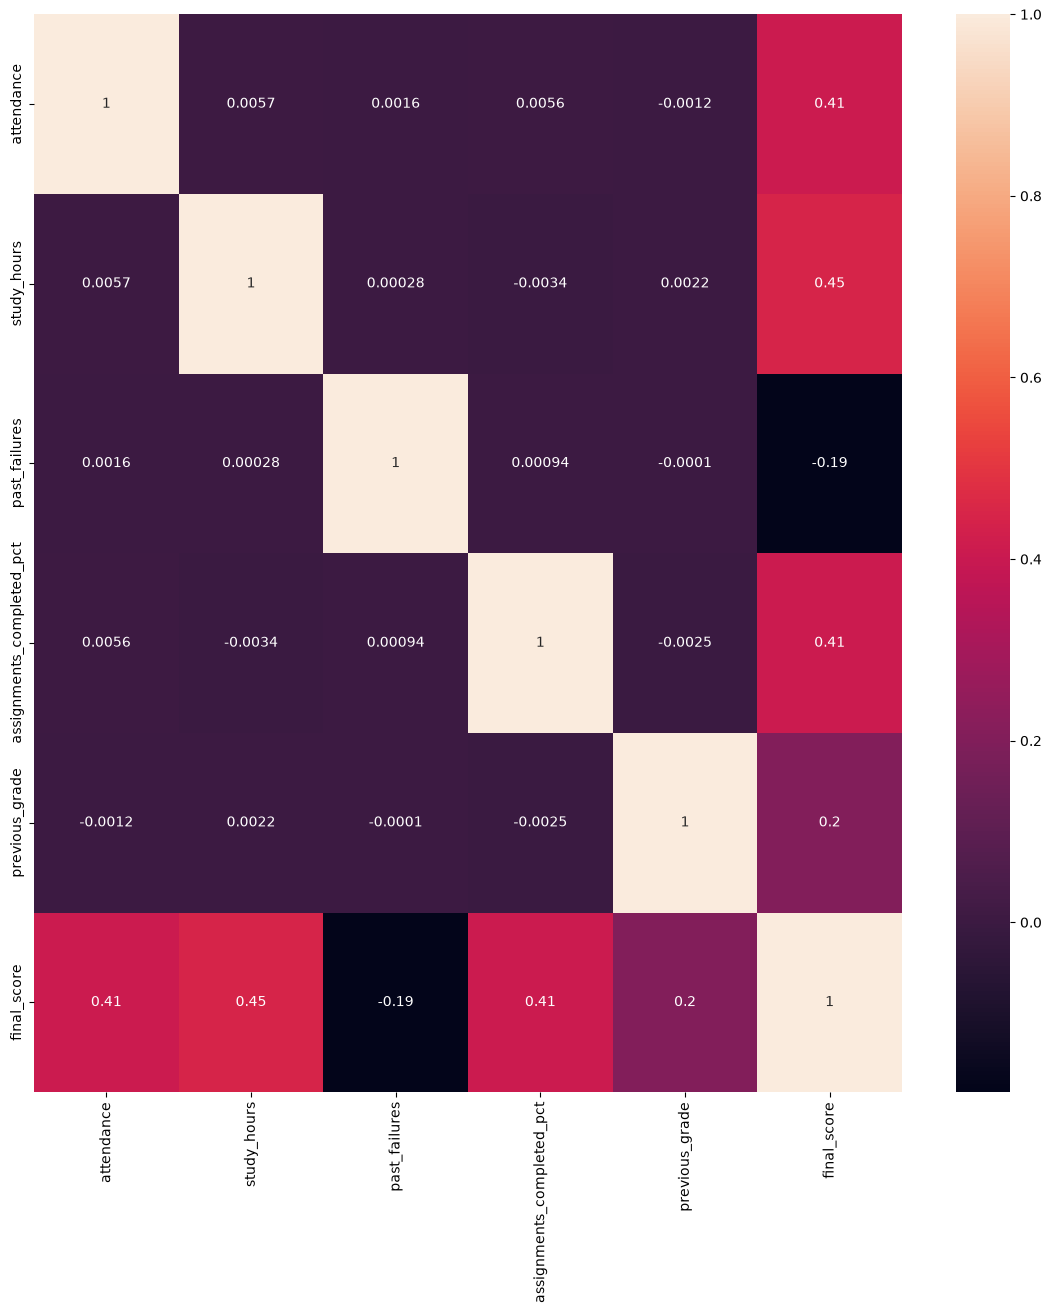

In [22]:
plt.figure(figsize=(14,14))
sns.heatmap(df.corr(numeric_only=True),annot=True)

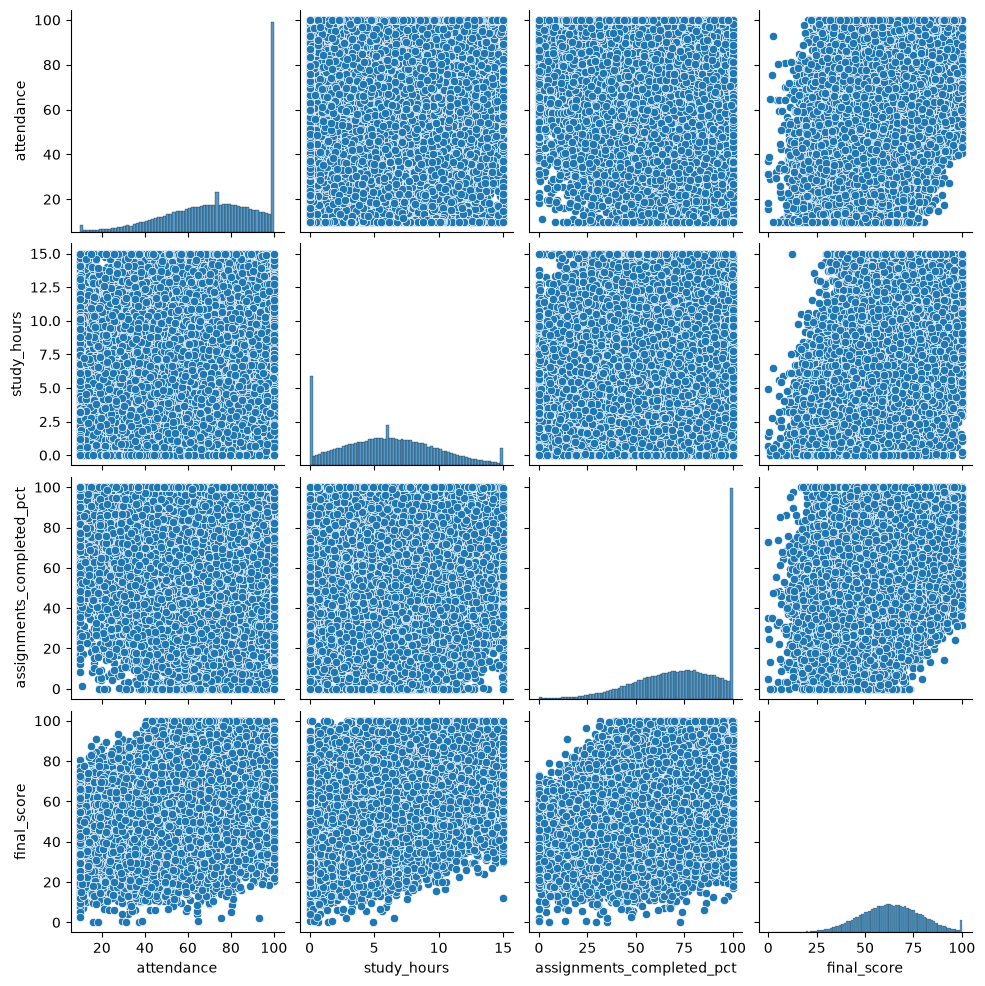

In [23]:
numeric_columns=['attendance','study_hours','assignments_completed_pct','final_score']
sns.pairplot(df[numeric_columns])

<Axes: xlabel='risk_category', ylabel='attendance'>

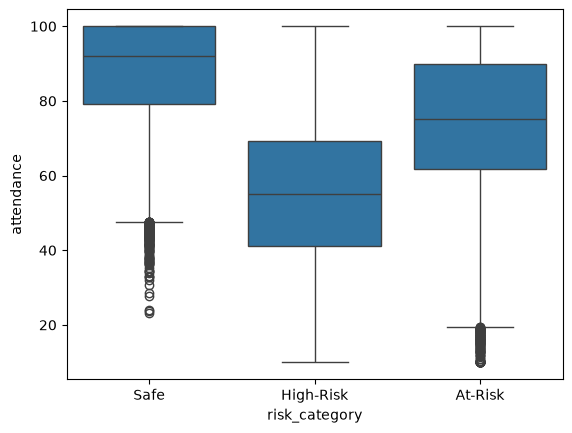

In [25]:
sns.boxplot(x='risk_category',y='attendance',data=df)